# Experiment: PCA With yfinance + Walk-Forward

This notebook fetches market data through `common.get_history` and evaluates PCA features using the same `common.walk_forward_splits` framework used by strategy scripts.

## Objectives
- Build a reproducible market feature set from yfinance.
- Compare baseline scaled features vs PCA-compressed features by walk-forward fold.
- Check PCA stability (variance capture and loading drift) across folds.


In [8]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

root = Path.cwd()
if root.name == "common":
    repo_root = root.parent
elif (root / "common").exists():
    repo_root = root
else:
    raise RuntimeError("Run this notebook from repo root or the common/ directory.")

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from common import get_history, parse_window, walk_forward_splits

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)


## Configuration

These defaults mirror your existing scripts: daily bars, rolling walk-forward windows, and embargo equal to forward target horizon.


In [9]:
TICKER_TARGET = "XLK"
TICKER_SPY = "SPY"
TICKER_GLD = "GLD"
TICKER_VIX = "^VIX"

START_DATE = "2016-01-01"
END_DATE = None  # None -> latest available
INTERVAL = "1d"
AUTO_ADJUST = True

TRAIN_WINDOW = "2y"
TEST_WINDOW = "1m"
STEP_WINDOW = "1m"
TARGET_HORIZON = 5
EMBARGO_BDAYS = TARGET_HORIZON
MIN_TRAIN_ROWS = 120

PCA_VAR_THRESHOLD = 0.80
MAX_PCS = 12
RIDGE_ALPHA = 1.0

print("Target:", TICKER_TARGET)
print("Walk-forward:", TRAIN_WINDOW, TEST_WINDOW, STEP_WINDOW, "embargo=", EMBARGO_BDAYS)


Target: XLK
Walk-forward: 2y 1m 1m embargo= 5


## Fetch via `common.get_history` + build dataset


In [10]:
def _normalize_history_index(history: pd.DataFrame) -> pd.DataFrame:
    out = history.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        raise ValueError("History must have a DatetimeIndex.")
    idx = out.index
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    out.index = idx.normalize()
    out = out.sort_index()
    return out


def fetch_history_map(
    tickers: list[str],
    start: str,
    end: str | None,
    interval: str = "1d",
    auto_adjust: bool = True,
) -> dict[str, pd.DataFrame]:
    end_exclusive = None
    if end is not None:
        # yfinance treats end as exclusive; bump by one day so user end is inclusive.
        end_exclusive = (pd.Timestamp(end).normalize() + pd.Timedelta(days=1)).date().isoformat()

    out: dict[str, pd.DataFrame] = {}
    for symbol in tickers:
        hist = get_history(
            symbol=symbol,
            period=None,
            interval=interval,
            start=pd.Timestamp(start).date().isoformat(),
            end=end_exclusive,
            auto_adjust=auto_adjust,
        )
        out[symbol] = _normalize_history_index(hist)
    return out


def _log_return(series: pd.Series, window: int = 1) -> pd.Series:
    ratio = (series / series.shift(window)).replace(0.0, np.nan)
    ret = np.log(ratio)
    return ret.replace([np.inf, -np.inf], np.nan)


def build_pca_dataset(
    history_map: dict[str, pd.DataFrame],
    target_ticker: str,
    spy_ticker: str,
    gld_ticker: str,
    vix_ticker: str,
    target_horizon: int,
) -> pd.DataFrame:
    req = [target_ticker, spy_ticker, gld_ticker, vix_ticker]
    missing = [t for t in req if t not in history_map]
    if missing:
        raise ValueError(f"Missing ticker histories: {missing}")

    px_target = history_map[target_ticker]["Close"].rename("px_target")
    vol_target = history_map[target_ticker]["Volume"].rename("vol_target")
    px_spy = history_map[spy_ticker]["Close"].rename("px_spy")
    px_gld = history_map[gld_ticker]["Close"].rename("px_gld")
    px_vix = history_map[vix_ticker]["Close"].rename("px_vix")

    frame = pd.concat([px_target, vol_target, px_spy, px_gld, px_vix], axis=1, join="inner")
    if frame.empty:
        raise ValueError("No overlapping dates after joining ticker histories.")

    ret_target_1d = _log_return(frame["px_target"], 1)
    ret_spy_1d = _log_return(frame["px_spy"], 1)
    ret_gld_1d = _log_return(frame["px_gld"], 1)
    ret_vix_1d = _log_return(frame["px_vix"], 1)

    out = pd.DataFrame(index=frame.index)

    # Target-side features
    out["ret_1d"] = ret_target_1d
    out["ret_5d"] = _log_return(frame["px_target"], 5)
    out["ret_10d"] = _log_return(frame["px_target"], 10)
    out["vol_5d"] = ret_target_1d.rolling(5).std()
    out["vol_20d"] = ret_target_1d.rolling(20).std()
    out["ma20_gap"] = (frame["px_target"] / frame["px_target"].rolling(20).mean()) - 1.0
    out["ma60_gap"] = (frame["px_target"] / frame["px_target"].rolling(60).mean()) - 1.0
    out["drawdown_60d"] = (frame["px_target"] / frame["px_target"].rolling(60).max()) - 1.0
    out["vol_ratio_5_20"] = (out["vol_5d"] / out["vol_20d"]).replace([np.inf, -np.inf], np.nan)

    vol_mean_20 = frame["vol_target"].rolling(20).mean()
    vol_std_20 = frame["vol_target"].rolling(20).std().replace(0.0, np.nan)
    out["volume_z20"] = (frame["vol_target"] - vol_mean_20) / vol_std_20

    # Cross-asset features
    out["spy_ret_1d"] = ret_spy_1d
    out["spy_vol_20d"] = ret_spy_1d.rolling(20).std()
    out["spy_ma20_gap"] = (frame["px_spy"] / frame["px_spy"].rolling(20).mean()) - 1.0
    out["gld_ret_1d"] = ret_gld_1d
    out["gld_ret_5d"] = _log_return(frame["px_gld"], 5)
    out["vix_ret_1d"] = ret_vix_1d

    vix_mean_60 = frame["px_vix"].rolling(60).mean()
    vix_std_60 = frame["px_vix"].rolling(60).std().replace(0.0, np.nan)
    out["vix_level_z60"] = (frame["px_vix"] - vix_mean_60) / vix_std_60

    # Forward target: log return over horizon.
    out["target"] = _log_return(frame["px_target"], target_horizon).shift(-target_horizon)

    out = out.dropna().sort_index()
    if out.empty:
        raise ValueError("No rows left after feature/target alignment.")
    return out


In [11]:
tickers = [TICKER_TARGET, TICKER_SPY, TICKER_GLD, TICKER_VIX]
histories = fetch_history_map(
    tickers=tickers,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL,
    auto_adjust=AUTO_ADJUST,
)

dataset = build_pca_dataset(
    history_map=histories,
    target_ticker=TICKER_TARGET,
    spy_ticker=TICKER_SPY,
    gld_ticker=TICKER_GLD,
    vix_ticker=TICKER_VIX,
    target_horizon=TARGET_HORIZON,
)

feature_cols = [c for c in dataset.columns if c != "target"]

train_offset = parse_window(TRAIN_WINDOW)
test_offset = parse_window(TEST_WINDOW)
min_required_end = dataset.index.min() + train_offset + pd.offsets.BDay(EMBARGO_BDAYS) + test_offset
if dataset.index.max() <= min_required_end:
    raise ValueError(
        "Not enough aligned data for configured windows after feature build. "
        "Try a longer lookback or shorter train/test windows."
    )

print(f"Rows: {len(dataset):,} | Features: {len(feature_cols):,}")
print(f"Date range: {dataset.index.min().date()} -> {dataset.index.max().date()}")
dataset.head()


Rows: 2,475 | Features: 17
Date range: 2016-03-30 -> 2026-01-30


,ret_1d,ret_5d,ret_10d,vol_5d,vol_20d,ma20_gap,ma60_gap,drawdown_60d,vol_ratio_5_20,volume_z20,spy_ret_1d,spy_vol_20d,spy_ma20_gap,gld_ret_1d,gld_ret_5d,vix_ret_1d,vix_level_z60,target
Date,,,,,,,,,,,,,,,,,,
2016-03-30,0.005867,0.015874,0.036349,0.008236,0.006210,0.034267,0.081742,0.000000,1.326323,0.332916,0.004378,0.005590,0.021301,-0.014076,-0.018697,-0.018992,-1.692690,0.001798
2016-03-31,-0.002027,0.019577,0.022782,0.007354,0.006305,0.029463,0.078544,-0.002025,1.166367,1.478660,-0.002430,0.005656,0.016922,0.004601,0.008794,0.028355,-1.539361,-0.010651
2016-04-01,0.007635,0.024457,0.026753,0.007484,0.006369,0.034230,0.085600,0.000000,1.175095,-0.293638,0.006789,0.005747,0.021785,-0.006054,0.005144,-0.062867,-1.674248,-0.018287
2016-04-04,-0.003810,0.023172,0.021335,0.007817,0.006549,0.027534,0.080116,-0.003803,1.193673,-1.004539,-0.003243,0.005855,0.016757,-0.006693,-0.003867,0.074980,-1.391057,-0.017214
2016-04-05,-0.009703,-0.002038,0.008197,0.007153,0.006843,0.015092,0.068006,-0.013423,1.045341,0.206502,-0.010038,0.006417,0.005455,0.012917,-0.009306,0.088073,-1.061102,-0.000681


## Walk-forward fold runner (aligned with `common.walk_forward_splits`)


In [12]:
@dataclass
class FoldArtifacts:
    fold: int
    explained_var_ratio: np.ndarray
    pc1_loadings: np.ndarray


def select_k_by_variance(explained_var_ratio: np.ndarray, threshold: float, max_pcs: int) -> int:
    cumulative = np.cumsum(explained_var_ratio)
    k = int(np.searchsorted(cumulative, threshold) + 1)
    return max(1, min(k, max_pcs, len(explained_var_ratio)))


def fold_regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
        "directional_acc": float((np.sign(y_true) == np.sign(y_pred)).mean()),
    }


def run_fold(split, feature_columns: list[str]) -> tuple[dict[str, float | int | str], FoldArtifacts]:
    train_df = split.train.copy()
    test_df = split.test.copy()

    preprocess = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    X_train_scaled = preprocess.fit_transform(train_df[feature_columns])
    X_test_scaled = preprocess.transform(test_df[feature_columns])

    pca = PCA()
    train_scores = pca.fit_transform(X_train_scaled)
    test_scores = pca.transform(X_test_scaled)

    k = select_k_by_variance(pca.explained_variance_ratio_, PCA_VAR_THRESHOLD, MAX_PCS)

    baseline_model = Ridge(alpha=RIDGE_ALPHA)
    baseline_model.fit(X_train_scaled, train_df["target"])
    baseline_pred = baseline_model.predict(X_test_scaled)

    pca_model = Ridge(alpha=RIDGE_ALPHA)
    pca_model.fit(train_scores[:, :k], train_df["target"])
    pca_pred = pca_model.predict(test_scores[:, :k])

    baseline_metrics = fold_regression_metrics(test_df["target"], baseline_pred)
    pca_metrics = fold_regression_metrics(test_df["target"], pca_pred)

    cumulative = np.cumsum(pca.explained_variance_ratio_)

    row = {
        "fold": split.fold,
        "train_start": str(split.train_start.date()),
        "train_end": str(split.train_end.date()),
        "test_start": str(split.test_start.date()),
        "test_end": str(split.test_end.date()),
        "train_rows": int(len(train_df)),
        "test_rows": int(len(test_df)),
        "k": int(k),
        "cum_explained_k": float(cumulative[k - 1]),
        "baseline_rmse": baseline_metrics["rmse"],
        "pca_rmse": pca_metrics["rmse"],
        "baseline_r2": baseline_metrics["r2"],
        "pca_r2": pca_metrics["r2"],
        "baseline_dir_acc": baseline_metrics["directional_acc"],
        "pca_dir_acc": pca_metrics["directional_acc"],
    }

    artifacts = FoldArtifacts(
        fold=split.fold,
        explained_var_ratio=pca.explained_variance_ratio_.copy(),
        pc1_loadings=pca.components_[0].copy(),
    )

    return row, artifacts


In [13]:
splits = list(
    walk_forward_splits(
        data=dataset,
        train_window=TRAIN_WINDOW,
        test_window=TEST_WINDOW,
        embargo=EMBARGO_BDAYS,
        step=STEP_WINDOW,
        min_train_rows=MIN_TRAIN_ROWS,
    )
)

if not splits:
    raise ValueError("No walk-forward splits produced. Check windows, lookback, and embargo.")

rows = []
artifacts_by_fold: list[FoldArtifacts] = []
for split in splits:
    row, artifacts = run_fold(split, feature_cols)
    rows.append(row)
    artifacts_by_fold.append(artifacts)

results = pd.DataFrame(rows)

print(f"Folds: {len(results)}")
results[["fold", "test_start", "test_end", "k", "cum_explained_k", "baseline_rmse", "pca_rmse", "baseline_dir_acc", "pca_dir_acc"]]


Folds: 93


,fold,test_start,test_end,k,cum_explained_k,baseline_rmse,pca_rmse,baseline_dir_acc,pca_dir_acc
0,1,2018-04-09,2018-05-04,5,0.801031,0.026296,0.026558,0.650000,0.650000
1,2,2018-05-08,2018-06-07,5,0.808866,0.013396,0.013595,0.818182,0.727273
2,3,2018-06-07,2018-07-06,5,0.810446,0.019479,0.020401,0.666667,0.523810
3,4,2018-07-09,2018-08-06,5,0.810456,0.017441,0.017336,0.619048,0.714286
4,5,2018-08-07,2018-09-06,5,0.810212,0.015054,0.014290,0.681818,0.681818
...,...,...,...,...,...,...,...,...,...
88,89,2025-08-05,2025-09-04,5,0.831534,0.023121,0.023036,0.500000,0.363636
89,90,2025-09-05,2025-10-03,5,0.830023,0.028367,0.024729,0.142857,0.238095
90,91,2025-10-06,2025-11-03,5,0.827412,0.032857,0.029996,0.428571,0.428571
91,92,2025-11-05,2025-12-04,5,0.830012,0.032351,0.031011,0.666667,0.666667


## Fold summary and diagnostics


In [14]:
summary = pd.DataFrame(
    {
        "baseline_rmse_mean": [results["baseline_rmse"].mean()],
        "pca_rmse_mean": [results["pca_rmse"].mean()],
        "baseline_r2_mean": [results["baseline_r2"].mean()],
        "pca_r2_mean": [results["pca_r2"].mean()],
        "baseline_dir_acc_mean": [results["baseline_dir_acc"].mean()],
        "pca_dir_acc_mean": [results["pca_dir_acc"].mean()],
        "k_mean": [results["k"].mean()],
        "cum_explained_k_mean": [results["cum_explained_k"].mean()],
    }
)
summary.T


,0
baseline_rmse_mean,0.032122
pca_rmse_mean,0.030903
baseline_r2_mean,-0.638710
pca_r2_mean,-0.490361
baseline_dir_acc_mean,0.540226
pca_dir_acc_mean,0.522451
k_mean,5.064516
cum_explained_k_mean,0.830324


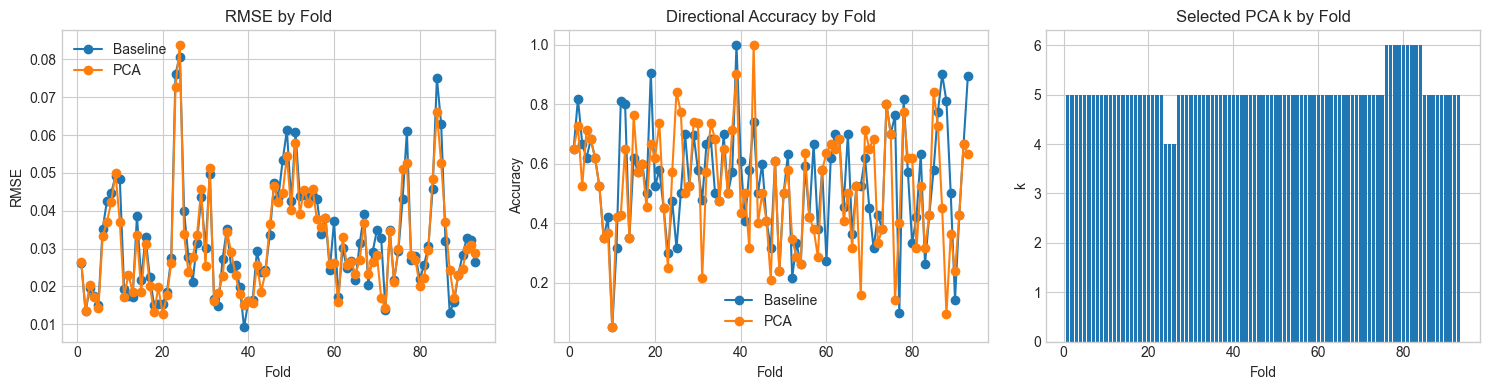

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results["fold"], results["baseline_rmse"], marker="o", label="Baseline")
axes[0].plot(results["fold"], results["pca_rmse"], marker="o", label="PCA")
axes[0].set_title("RMSE by Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("RMSE")
axes[0].legend()

axes[1].plot(results["fold"], results["baseline_dir_acc"], marker="o", label="Baseline")
axes[1].plot(results["fold"], results["pca_dir_acc"], marker="o", label="PCA")
axes[1].set_title("Directional Accuracy by Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

axes[2].bar(results["fold"], results["k"])
axes[2].set_title("Selected PCA k by Fold")
axes[2].set_xlabel("Fold")
axes[2].set_ylabel("k")

plt.tight_layout()


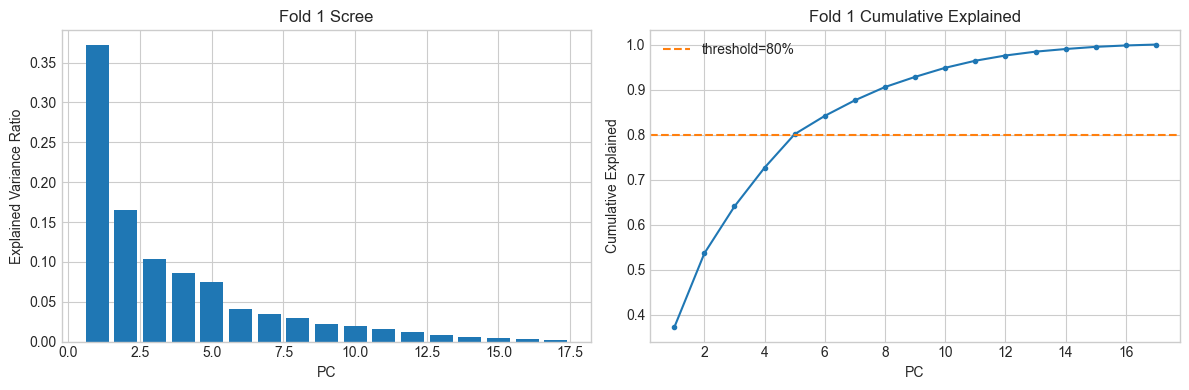

In [16]:
# Scree plot for first fold (train period only)
first = artifacts_by_fold[0]
explained = first.explained_var_ratio
cumulative = np.cumsum(explained)
max_pc = min(20, len(explained))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(np.arange(1, max_pc + 1), explained[:max_pc])
ax[0].set_title(f"Fold {first.fold} Scree")
ax[0].set_xlabel("PC")
ax[0].set_ylabel("Explained Variance Ratio")

ax[1].plot(np.arange(1, len(cumulative) + 1), cumulative, marker="o", ms=3)
ax[1].axhline(PCA_VAR_THRESHOLD, linestyle="--", color="tab:orange", label=f"threshold={PCA_VAR_THRESHOLD:.0%}")
ax[1].set_title(f"Fold {first.fold} Cumulative Explained")
ax[1].set_xlabel("PC")
ax[1].set_ylabel("Cumulative Explained")
ax[1].legend()

plt.tight_layout()


,fold,pc1_cosine_similarity
0,1,1.000000
1,2,0.998560
2,3,0.998225
3,4,0.996180
4,5,0.993385
...,...,...
88,89,0.993737
89,90,0.994299
90,91,0.994337
91,92,0.994816


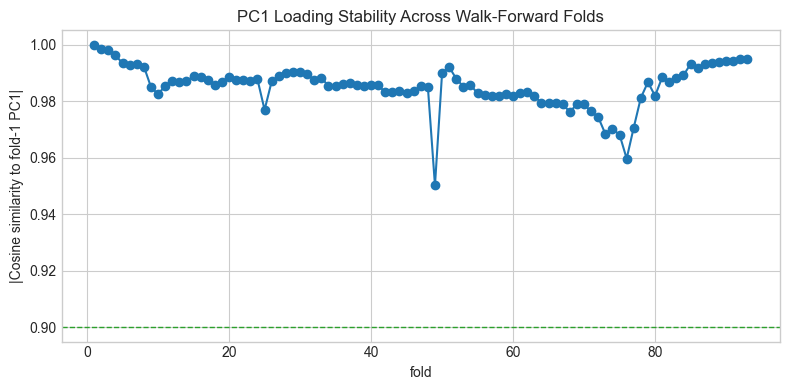

In [17]:
# PC1 loading drift across folds (cosine similarity vs fold 1)
ref = artifacts_by_fold[0].pc1_loadings
rows = []
for art in artifacts_by_fold:
    sim = float(np.dot(ref, art.pc1_loadings) / (np.linalg.norm(ref) * np.linalg.norm(art.pc1_loadings)))
    rows.append({"fold": art.fold, "pc1_cosine_similarity": abs(sim)})

stability = pd.DataFrame(rows)
ax = stability.plot(x="fold", y="pc1_cosine_similarity", marker="o", figsize=(8, 4), legend=False)
ax.axhline(0.9, linestyle="--", color="tab:green", linewidth=1)
ax.set_title("PC1 Loading Stability Across Walk-Forward Folds")
ax.set_ylabel("|Cosine similarity to fold-1 PC1|")
plt.tight_layout()
stability


## Leakage checklist

- `walk_forward_splits` enforces chronological train/test segmentation.
- Embargo is set to `TARGET_HORIZON` business days to match forward target construction.
- Imputer/scaler/PCA are fit on each train fold only, then applied to test fold.
- Replace Ridge proxy with your actual strategy/backtest model if you want production-like performance numbers.
